In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def read_valid_pixels(tif_path):
    with rasterio.open(tif_path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata

    if nodata is not None:
        data[data == nodata] = np.nan

    return data[~np.isnan(data)]

In [8]:
hist_files = {
    "2012": "2012_DEM.tif",
    "2013": "2013_DEM.tif",
#    "2014": "2014_DEM.tif",
    "2015": "2015_DEM.tif",
}

hist_data = {label: read_valid_pixels(path)
             for label, path in hist_files.items()}

In [9]:
colors = {
    "2012": "#2171b5",  # blue
    "2013": "#31a354",  # green
    "2015": "#8c6d31",  # brown
}

plt.rcParams.update({
    "font.family": "Arial",  
    "font.size": 18, 
    "axes.labelsize": 18, 
    "axes.titlesize": 18, 
    "xtick.labelsize": 14, 
    "ytick.labelsize": 14,
    "legend.fontsize": 14,  
    "axes.linewidth": 1.0,  
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

# Creating consistent bins
all_values = np.concatenate(list(hist_data.values()))
bins = np.linspace(np.min(all_values), np.max(all_values), 20)
bin_width = bins[1] - bins[0]
bin_centers = bins[:-1] + bin_width / 2

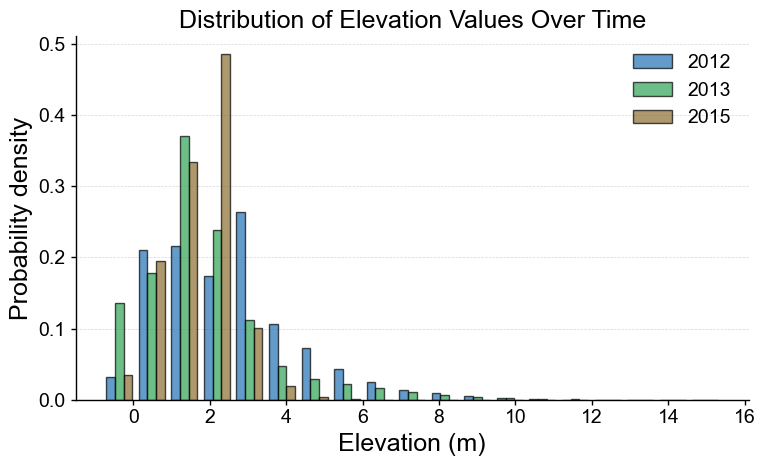

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

n_years = len(hist_data)
group_width = bin_width * 0.8
bar_width = group_width / n_years

for i, (label, data) in enumerate(hist_data.items()):
    counts, _ = np.histogram(data, bins=bins, density=True)
    ax.bar(
        bin_centers + i * bar_width - (n_years-1)/2*bar_width,
        counts,
        width=bar_width,
        color=colors[label],
        alpha=0.7,
        edgecolor="black",
        linewidth=1,
        label=label
    )

# Axes labels
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Probability density")
ax.set_title("Distribution of Elevation Values Over Time")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()